Iniciando análisis de rozamiento de rotación...
Cargando y procesando datos para análisis de rotación...


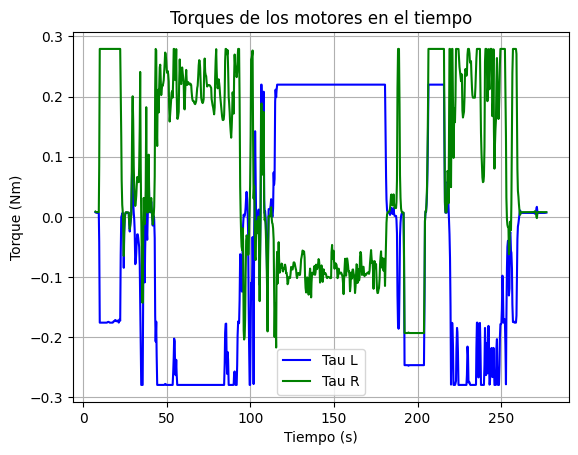

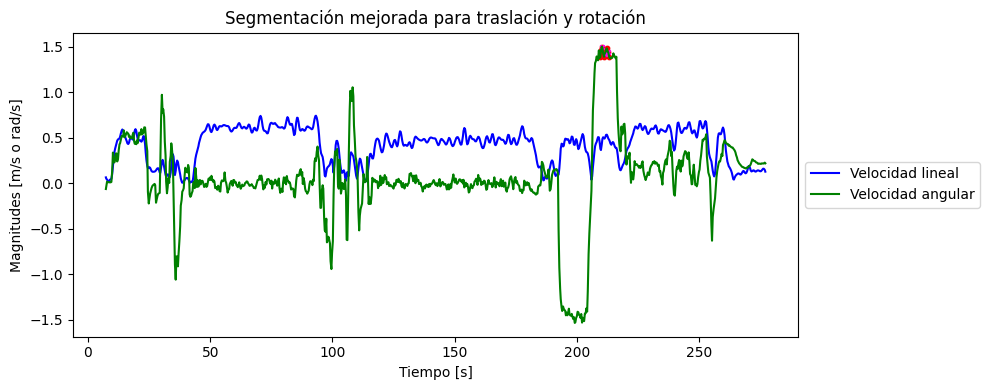

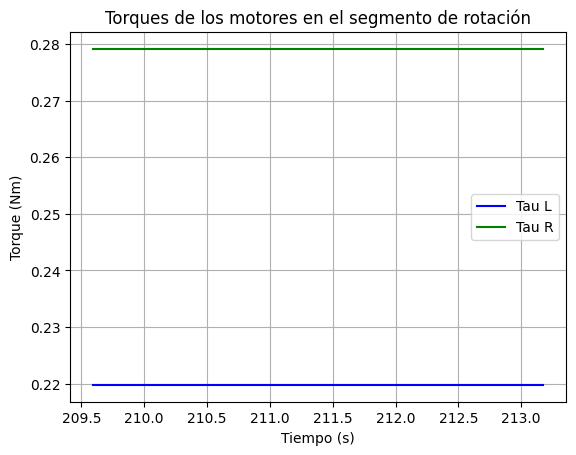

Momento de inercia estimado: 4.00 kg·m²


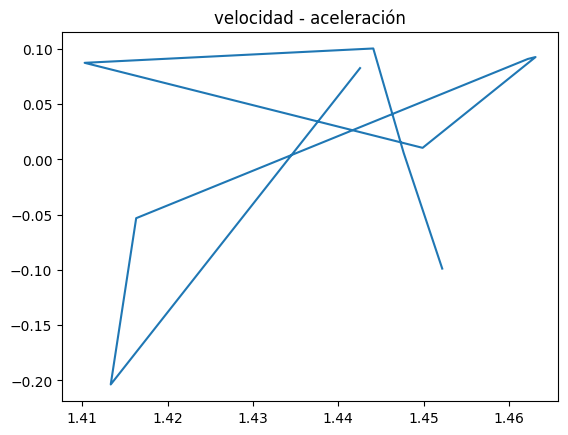

mu_w_lin =  0.2
mu_w_lin =  0.2000000149011612
mu_w_lin =  0.31296272319600305
mu_w_lin =  0.31296273809716424
mu_w_lin =  0.31296272319600305


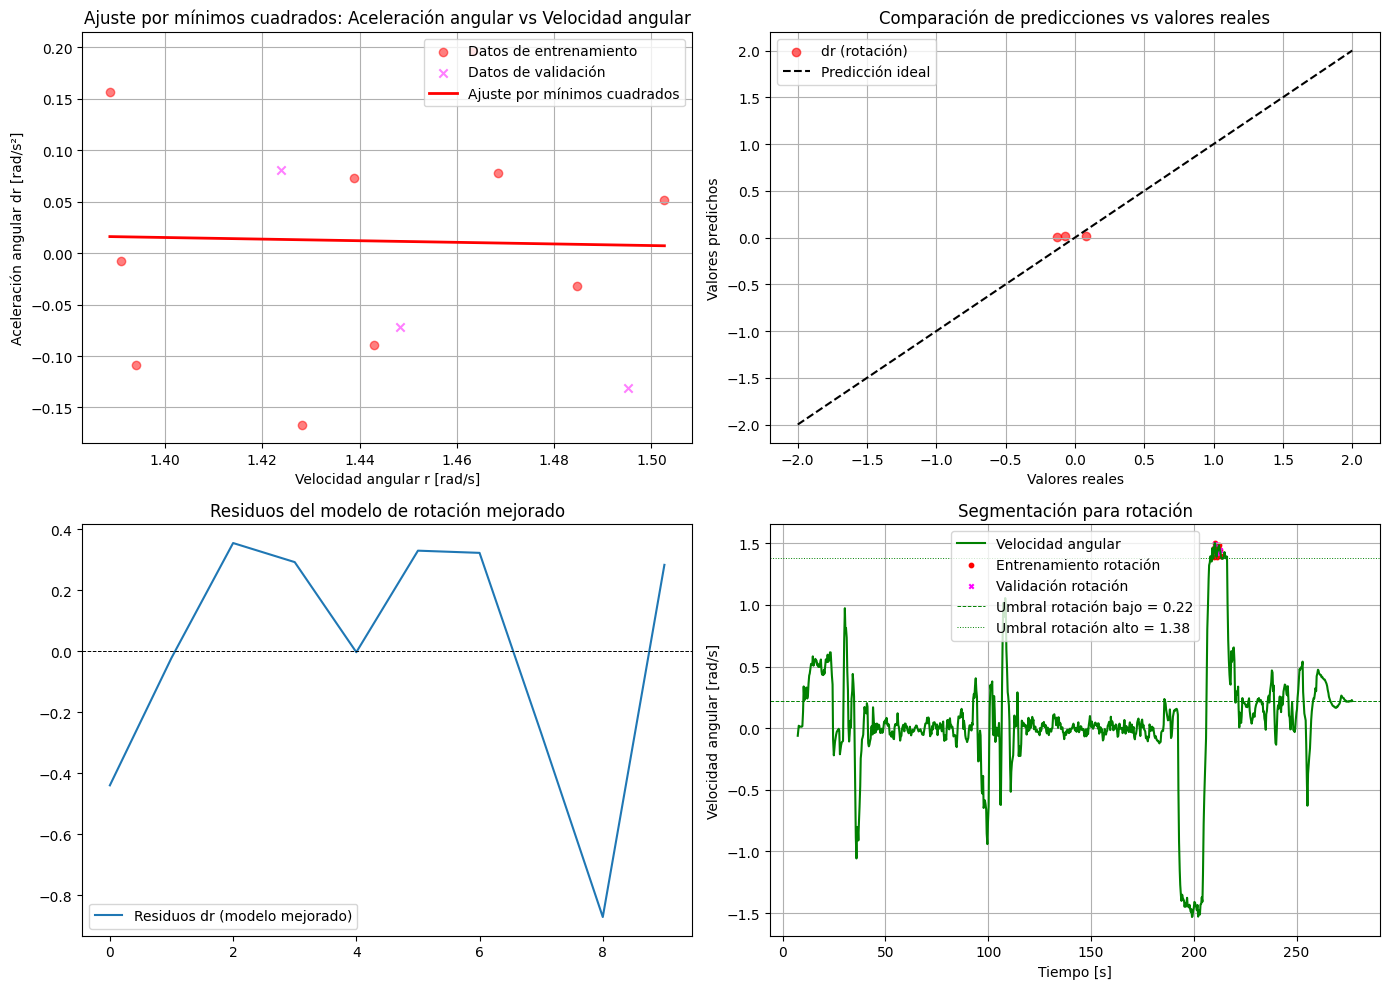

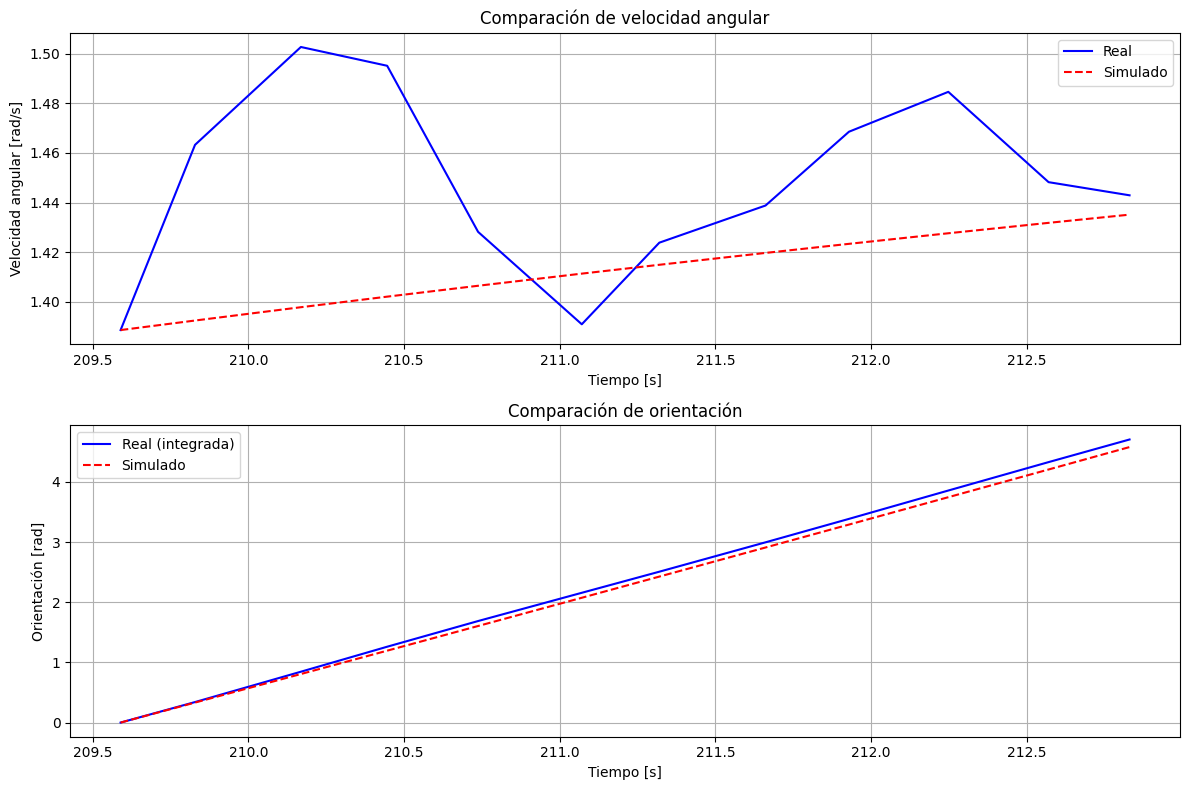


--- Estimación del modelo de rotación mejorado ---
Umbral rotación bajo: 0.22
Umbral rotación alto: 1.38

Coeficientes de rotación (modelo mejorado):
mu_w_lin = 0.312963 (término constante/sesgo)

--- Validación cruzada ---
MSE rotación: 0.010232


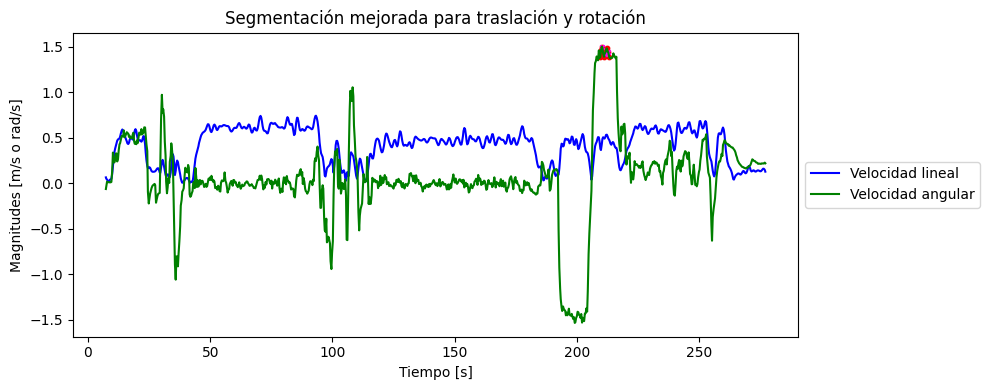


Análisis de rotación completado con éxito.
Los resultados se han guardado en los archivos 'ajuste_rotacion.png' y 'simulacion_rotacion.png'


In [18]:
#!/usr/bin/env python
# coding: utf-8

"""
Análisis de rozamiento de rotación para vehículo marino

Este script se enfoca exclusivamente en el análisis del rozamiento de rotación,
separado del análisis de traslación.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
from scipy.signal import butter, filtfilt
from scipy.signal import savgol_filter

# Funciones auxiliares
def extraccion_datos(var, pos):
    """
    Extrae datos de un archivo de registro.
    
    Args:
        var: Variable a extraer
        pos: Posición de la variable en la línea
    
    Returns:
        Tupla con los datos extraídos y sus tiempos correspondientes
    """
    home_dir = os.path.expanduser("~")
    ruta_datos = os.path.join(home_dir, "paparazzi", "var", "logs", "25_05_28__16_27_03.data")
    
    dato = []
    tiempo = []
    with open(ruta_datos, "r", encoding="utf-8") as file:
        for line in file:
            if var in line:
                campos = line.strip().split()
                if campos[2] == var:
                    dato.append(float(campos[pos]))
                    tiempo.append(float(campos[0]))
    return np.array(dato), np.array(tiempo)


def filtrado_tiempo_comun(t_comun, dt_min=0.1, dt_max=1):
    """
    Filtra los tiempos para obtener intervalos regulares.
    
    Args:
        t_comun: Array de tiempos a filtrar
        dt_min: Intervalo mínimo entre muestras
        dt_max: Intervalo máximo entre muestras
    
    Returns:
        Tiempos filtrados e índices correspondientes
    """
    dt = np.gradient(t_comun)
    mask = (dt >= dt_min) & (dt <= dt_max)
    mask[0] = True
    indices = np.where(mask)[0]
    t_filtrado = t_comun[indices]
    
    return t_filtrado, indices


def interp_to_common(t_original, data_original, t_comun):
    """
    Interpola datos a una base de tiempo común.
    
    Args:
        t_original: Tiempos originales
        data_original: Datos originales
        t_comun: Base de tiempo común para interpolación
    
    Returns:
        Datos interpolados
    """
    interp_func = interp1d(t_original, data_original, kind='linear', bounds_error=False, fill_value="extrapolate")
    return interp_func(t_comun)

def normalize_angle(angle):
    """
    Normaliza un ángulo al rango [-π, π].
    
    Args:
        angle: Ángulo a normalizar
        
    Returns:
        Ángulo normalizado
    """
    return ((angle + np.pi) % (2 * np.pi)) - np.pi

def filtro_butterworth(data, cutoff_freq, fs, order=4):
    """
    Aplica un filtro Butterworth pasa-bajos.
    
    Args:
        data: Datos a filtrar
        cutoff_freq: Frecuencia de corte (Hz)
        fs: Frecuencia de muestreo (Hz)
        order: Orden del filtro
        
    Returns:
        Datos filtrados
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def safe_multiply(a, b, max_val=1e6):
    """
    Multiplicación segura que evita desbordamientos.
    
    Args:
        a, b: Valores a multiplicar
        max_val: Valor máximo permitido
        
    Returns:
        Resultado de la multiplicación, limitado a max_val
    """
    try:
        result = a * b
        if np.isscalar(result):
            if not np.isfinite(result) or abs(result) > max_val:
                return np.sign(result) * max_val if result != 0 else 0.0
            return result
        else:
            # Manejar arrays
            result = np.where(np.isfinite(result), result, np.sign(result) * max_val)
            result = np.where(np.abs(result) <= max_val, result, np.sign(result) * max_val)
            # Corregir casos donde el signo es 0
            result = np.where(result == 0, 0.0, result)
            return result
    except Exception as e:
        print(f"Error en safe_multiply: {e}")
        if np.isscalar(a) and np.isscalar(b):
            return 0.0
        else:
            return np.zeros_like(a if hasattr(a, 'shape') else b)

def safe_add(a, b, max_val=1e6):
    """
    Suma segura que evita desbordamientos.
    
    Args:
        a, b: Valores a sumar
        max_val: Valor máximo permitido
        
    Returns:
        Resultado de la suma, limitado a max_val
    """
    try:
        result = a + b
        if np.isscalar(result):
            if not np.isfinite(result) or abs(result) > max_val:
                return np.sign(result) * max_val if result != 0 else 0.0
            return result
        else:
            # Manejar arrays
            result = np.where(np.isfinite(result), result, np.sign(result) * max_val)
            result = np.where(np.abs(result) <= max_val, result, np.sign(result) * max_val)
            # Corregir casos donde el signo es 0
            result = np.where(result == 0, 0.0, result)
            return result
    except Exception as e:
        print(f"Error en safe_add: {e}")
        if np.isscalar(a) and np.isscalar(b):
            return 0.0
        else:
            return np.zeros_like(a if hasattr(a, 'shape') else b)

def limit_angular_velocity(angular_velocity, max_angular_vel=1.0):
    """
    Limita la velocidad angular a un valor máximo físicamente razonable.
    
    Args:
        angular_velocity: Valor de velocidad angular a limitar
        max_angular_vel: Velocidad angular máxima permitida en rad/s
        
    Returns:
        Velocidad angular limitada al rango [-max_angular_vel, max_angular_vel]
    """
    return np.clip(angular_velocity, -max_angular_vel, max_angular_vel)

def rk4_step(y, t, dt, f):
    """
    Integración mediante Runge-Kutta de 4º orden.
    
    Args:
        y: Estado actual
        t: Tiempo actual
        dt: Paso de tiempo
        f: Función que calcula la derivada del estado
        
    Returns:
        Nuevo estado
    """
    k1 = f(y, t)
    k2 = f(y + dt/2 * k1, t + dt/2)
    k3 = f(y + dt/2 * k2, t + dt/2)
    k4 = f(y + dt * k3, t + dt)
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def verificar_consistencia_orientacion(theta_sim, orientacion_real, t_sim, ventana=50):
    """
    Verifica la consistencia entre orientación simulada y real.
    
    Args:
        theta_sim: Orientación simulada
        orientacion_real: Orientación real
        t_sim: Tiempos de simulación
        ventana: Tamaño de la ventana de análisis
        
    Returns:
        Orientación simulada corregida
    """
    theta_corregida = theta_sim.copy()
    
    for i in range(ventana, len(t_sim)):
        # Calcular error medio en la ventana anterior
        error_medio = np.mean(np.abs(normalize_angle(
            orientacion_real[i-ventana:i] - theta_sim[i-ventana:i])))
        
        # Si el error supera un umbral, aplicar corrección
        if error_medio > np.pi/3:  # Más de 60 grados de error promedio
            print(f"Corrección aplicada en t={t_sim[i]}, error={error_medio}")
            # Reiniciar la orientación simulada al valor real
            theta_corregida[i] = orientacion_real[i]
            # Propagar la corrección a los siguientes pasos
            if i+1 < len(t_sim):
                theta_corregida[i+1:] = theta_sim[i+1:] + (orientacion_real[i] - theta_sim[i])
            break
    
    return theta_corregida

def calcular_torque_mejorado(T_L, T_R, distancia_motores, v_lineal, omega):
    """
    Calcula el torque con un modelo mejorado que considera efectos adicionales.
    
    Args:
        T_L, T_R: Fuerzas de los motores izquierdo y derecho
        distancia_motores: Distancia entre motores
        v_lineal: Velocidad lineal
        omega: Velocidad angular
        
    Returns:
        Torque total
    """
    # Torque básico de los motores
    tau_motores = -distancia_motores * T_L + distancia_motores * T_R
    
    # Factor de eficiencia que disminuye a velocidades altas
    eficiencia = 1.0 / (1.0 + 0.1 * v_lineal)
    
    # Torque efectivo
    tau_efectivo = tau_motores * eficiencia
    
    return tau_efectivo

def tramo_minima_dependencia(indices, v_lineal, omega_abs, tipo='rotacion', min_length=10):
    """
    Selecciona el tramo continuo que minimiza la dependencia cruzada.
    
    Args:
        indices: Array de índices a analizar
        v_lineal: Array de velocidades lineales
        omega_abs: Array de velocidades angulares absolutas
        tipo: 'traslacion' o 'rotacion', indica el tipo de tramo a seleccionar
        min_length: Longitud mínima que debe tener un segmento para ser considerado
        
    Returns:
        Array con el segmento que minimiza la dependencia cruzada
    """
    if len(indices) == 0:
        return indices
    
    # Detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    
    # Filtra segmentos de al menos longitud mínima
    segmentos_validos = [seg for seg in segmentos if len(seg) >= min_length]
    
    if not segmentos_validos:
        return np.array([], dtype=int)
    
    # Calcula la métrica de dependencia para cada segmento
    if tipo == 'traslacion':
        # Para traslación, queremos minimizar la velocidad angular
        metricas = [np.mean(omega_abs[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad lineal para favorecer segmentos con alta velocidad lineal
        metricas_normalizadas = [metricas[i] / (np.mean(v_lineal[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
        
    elif tipo == 'rotacion':
        # Para rotación, queremos minimizar la velocidad lineal
        metricas = [np.mean(v_lineal[seg]) for seg in segmentos_validos]
        # Normalizar por la velocidad angular para favorecer segmentos con alta velocidad angular
        metricas_normalizadas = [metricas[i] / (np.mean(omega_abs[seg]) + 1e-6) 
                               for i, seg in enumerate(segmentos_validos)]
        # Seleccionar el segmento con la menor métrica normalizada
        mejor_segmento = segmentos_validos[np.argmin(metricas_normalizadas)]
    
    return mejor_segmento

def tramo_mas_largo(indices):
    """
    Devuelve el sub-array continuo más largo dentro de `indices`.
    
    Args:
        indices: Array de índices a analizar
        
    Returns:
        Array con el segmento continuo más largo
    """
    if len(indices) == 0:
        return indices
    # detecta rupturas de continuidad
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    # filtra segmentos de al menos longitud 2
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # devuelve el más largo
    return max(segmentos_largos, key=len)

def tramo_mayor_velocidad(indices, velocidad):
    """
    Devuelve, dentro de los segmentos continuos en `indices`,
    aquel cuya velocidad (en el array `velocidad`) alcance el valor máximo.
    
    Args:
        indices: Array de índices a analizar
        velocidad: Array de velocidades correspondientes
        
    Returns:
        Array con el segmento que contiene la mayor velocidad
    """
    if len(indices) == 0:
        return indices
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    segmentos_largos = [seg for seg in segmentos if len(seg) > 1]
    if not segmentos_largos:
        return np.array([], dtype=int)
    # selecciona el segmento con mayor pico de velocidad
    return max(segmentos_largos, key=lambda seg: np.max(velocidad[seg]))

def tramo_velocidad_alta_constante(indices, omega_abs, umbral_std=0.05, min_length=2):
    """
    Devuelve el segmento continuo dentro de `indices` con mayor media de velocidad angular
    pero cuya desviación estándar sea menor que `umbral_std`, es decir, velocidad constante.
    
    Args:
        indices: Array de índices válidos
        omega_abs: Array de velocidades angulares absolutas
        umbral_std: Umbral máximo de desviación estándar para considerar velocidad constante
        min_length: Longitud mínima del segmento
        
    Returns:
        Array con el mejor segmento, o vacío si no hay ninguno que cumpla
    """
    if len(indices) == 0:
        return indices
    
    cortes = np.where(np.diff(indices) != 1)[0] + 1
    segmentos = np.split(indices, cortes)
    
    # Filtrar por longitud mínima y std baja (velocidad angular constante)
    segmentos_validos = [seg for seg in segmentos
                         if len(seg) >= min_length and np.std(omega_abs[seg]) < umbral_std]
    
    if not segmentos_validos:
        return np.array([], dtype=int)
    
    # Elegir el que tenga mayor velocidad angular media
    mejor_segmento = max(segmentos_validos, key=lambda seg: np.mean(omega_abs[seg]))
    
    return mejor_segmento

def split_train_validation(indices, train_ratio=0.8):
    """
    Divide los índices en conjuntos de entrenamiento y validación.
    
    Args:
        indices: Array de índices a dividir
        train_ratio: Proporción para el conjunto de entrenamiento (0-1)
        
    Returns:
        Tupla con (índices_entrenamiento, índices_validación)
    """
    n = len(indices)
    n_train = int(train_ratio * n)
    # Aseguramos que la división sea aleatoria pero reproducible
    np.random.seed(42)
    indices_shuffled = np.random.permutation(indices)
    train_indices = indices_shuffled[:n_train]
    valid_indices = indices_shuffled[n_train:]
    return train_indices, valid_indices

# Función específica para el análisis de rotación
def residuals_rot_mejorado(params):
    """
    Función de residuos para el movimiento de rotación con modelo mejorado.
    
    Args:
        params: [mu_w_const, mu_w_lin, mu_w_acoplamiento]
            mu_w_const: Término constante (sesgo)
            mu_w_lin: Coeficiente de fricción rotacional lineal
            mu_w_acoplamiento: Coeficiente de acoplamiento con velocidad lineal
    """
    #mu_w_const = params[0]
    mu_w_lin = params[0]
    # mu_w_acoplamiento = params[2]
    
    # Términos de fricción
    #friction_const = mu_w_const * np.sign(r_rot_smooth)
    friction_lin = mu_w_lin * r_rot_smooth
    # # Término de acoplamiento: fricción rotacional que depende de la velocidad lineal
    # friction_acoplamiento = mu_w_acoplamiento * r_rot_smooth * v_lineal_rot_smooth
    
    # Fricción total
    #friction_torque = friction_const + friction_lin + friction_acoplamiento
    friction_torque = friction_lin
    
    residuos = inercia_barco * dr_rot_smooth - (tau_rot - friction_torque)
    #residuos = dr_rot_smooth - (tau_rot - friction_torque)
    
    # Asegurar que los residuos sean finitos
    residuos = np.where(np.isfinite(residuos), residuos, 0.0)

    print("mu_w_lin = ", mu_w_lin)
    
    return residuos

def evaluate_model_rot_mejorado(params, indices):
    """
    Evalúa el modelo de rotación mejorado en los índices dados.
    
    Args:
        params: Parámetros del modelo [mu_w_const, mu_w_lin, mu_w_acoplamiento]
        indices: Índices donde evaluar el modelo
        
    Returns:
        Tupla con (dr_pred, mse_r)
    """
    r_eval = r[indices]
    dr_eval = dr[indices]
    tau_eval = tau_array[indices]
    v_lineal_eval = v_lineal[indices]
    
    # mu_w_const = params[0]
    mu_w_lin = params[0]
    # mu_w_acoplamiento = params[2]
    
    # Términos de fricción
    #friction_const = mu_w_const * np.sign(r_eval)
    friction_lin = mu_w_lin * r_eval
    # friction_acoplamiento = mu_w_acoplamiento * r_eval * v_lineal_eval
    
    # Fricción total
    #friction_torque = friction_const #+ friction_lin + friction_acoplamiento
    friction_torque = friction_lin
    # Predicción
    dr_pred = (tau_eval - friction_torque) / inercia_barco
    
    # Asegurar que las predicciones sean finitas
    dr_pred = np.where(np.isfinite(dr_pred), dr_pred, 0.0)
    
    # Error cuadrático medio
    mse_r = np.mean((dr_eval - dr_pred)**2)
    
    return dr_pred, mse_r

def simulate_motion_rotacion(t_sim, r0, tau_sim, params_rot, v_lineal_sim=None):
    """
    Simula el movimiento de rotación del vehículo.
    
    Args:
        t_sim: Array de tiempos para la simulación
        r0: Velocidad angular inicial
        tau_sim: Array de torques
        params_rot: Parámetros del modelo de rotación [mu_w_const, mu_w_lin, mu_w_acoplamiento]
        v_lineal_sim: Array de velocidades lineales (opcional)
        
    Returns:
        Tupla con (r_sim, theta_sim)
    """
    dt = np.diff(t_sim)
    n = len(t_sim)

    r_sim = np.zeros(n)
    theta_sim = np.zeros(n)

    max_vel_angular = 3.0  # rad/s

    r_sim[0] = limit_angular_velocity(r0, max_vel_angular)
    theta_sim[0] = 0  # Orientación inicial arbitraria
    
    # Si no se proporciona velocidad lineal, usamos un valor constante
    if v_lineal_sim is None:
        v_lineal_sim = np.ones(n) * 0.1  # Valor arbitrario bajo

    #mu_w_const = params_rot[0]
    mu_w_lin = params_rot[0]
    # mu_w_acoplamiento = params_rot[2]
    
    for i in range(1, n):
        r_prev = r_sim[i-1]
        theta_prev = theta_sim[i-1]
        v_lineal_rot_sim = v_lineal_sim[i-1]

        # TÉRMINOS DE ROTACIÓN
        #friction_const = mu_w_const * np.sign(r_prev)
        friction_lin = mu_w_lin * r_prev
        # friction_acoplamiento = mu_w_acoplamiento * r_prev * v_lineal_rot_sim
        
        #friction_torque = friction_const #+ friction_lin + friction_acoplamiento
        friction_torque = friction_lin
        dr_sim = (tau_sim[i-1] - friction_torque) * (1.0 / inercia_barco)

        r_next = r_prev + dr_sim * dt[i-1]
        r_sim[i] = limit_angular_velocity(r_next, max_vel_angular)

        r_avg = 0.5 * (r_prev + r_sim[i])
        theta_increment = r_avg * dt[i-1]
        theta_sim[i] = theta_prev + theta_increment

        r_sim[i] = 0.0 if not np.isfinite(r_sim[i]) else r_sim[i]

        if i > 1:
            if abs(r_sim[i]) > 1.5 * abs(r_sim[i-1]) and abs(r_sim[i]) > 0.5:
                r_sim[i] *= 0.8

    return r_sim, theta_sim

def analizar_rotacion():
    """
    Función principal para ejecutar el análisis de rotación.
    """
    global r, dr, T_L, T_R, v_lineal, omega_abs, distancia_motores, inercia_barco
    global indices_rot_train, indices_rot_valid, tau_array
    global r_rot_smooth, dr_rot_smooth, tau_rot, v_lineal_rot_smooth
    global t_filtrado, orientacion_i
    
    # Cargar y procesar datos
    print("Cargando y procesando datos para análisis de rotación...")
    
    # Extracción de datos
    escala_vel = 0.0000019
    u_raw, t_u = extraccion_datos("INS", 6)
    v_raw, t_v = extraccion_datos("INS", 7)

    # Aplicamos la transformación a las velocidades
    u_escalado_original = u_raw * escala_vel  # Velocidad en x original (derecha)
    v_escalado_original = v_raw * escala_vel  # Velocidad en y original (adelante)

    # Transformamos al sistema del modelo
    u_escalado = u_escalado_original  
    v_escalado = v_escalado_original 

    # Aplicamos la misma transformación a las aceleraciones
    escala_acc = 0.0009766
    du_raw, t_du = extraccion_datos("INS", 9)
    dv_raw, t_dv = extraccion_datos("INS", 10)

    du_scaled_original = du_raw * escala_acc  
    dv_scaled_original = dv_raw * escala_acc 

    # Transformamos al sistema del modelo
    du_scaled = du_scaled_original 
    dv_scaled = dv_scaled_original  

    orientacion_raw, t_orientacion = extraccion_datos("ATTITUDE", 4)
    w_raw, t_w = extraccion_datos("BODY_RATES_ACCEL", 5)
    throttle_L, t_T_L = extraccion_datos("BOAT_CTRL", 7)
    throttle_R, t_T_R = extraccion_datos("BOAT_CTRL", 8)
    throttle_L_norm = throttle_L / 9600
    throttle_R_norm = throttle_R / 9600

    # Parámetros físicos del barco
    masa_barco = 50  # kg
    distancia_motores = 0.75/2  # m

    orientacion_corregida = orientacion_raw
    # Aplicamos el ajuste para el nuevo sistema de coordenadas
    orientacion_unwrapped = np.unwrap(orientacion_corregida)

    t_comun = t_u
    # MEJORA: Ajuste del umbral de filtrado para obtener datos más consistentes
    t_filtrado, indices_filtrado = filtrado_tiempo_comun(t_comun, dt_min=0.2, dt_max=0.6)

    # Calcular frecuencia de muestreo promedio para filtrado
    fs = 1.0 / np.mean(np.diff(t_filtrado))
    cutoff_freq = 0.5  # Hz, ajustar según las características de la señal
    orientacion_filtered = -filtro_butterworth(orientacion_unwrapped, cutoff_freq, fs)

    # Interpolación
    u_interp = interp_to_common(t_u, u_escalado, t_filtrado)
    v_interp = interp_to_common(t_v, v_escalado, t_filtrado)
    du_interp = interp_to_common(t_du, du_scaled, t_filtrado)
    dv_interp = interp_to_common(t_dv, dv_scaled, t_filtrado)
    # Interpolar los datos de orientación ya desenrollados y filtrados
    orientacion_i = interp_to_common(t_orientacion, orientacion_filtered, t_filtrado)
    w_i = interp_to_common(t_w, w_raw, t_filtrado)
    throttle_L_i = interp_to_common(t_T_L, throttle_L_norm, t_filtrado)
    throttle_R_i = interp_to_common(t_T_R, throttle_R_norm, t_filtrado)

    # MEJORA: Filtrado de señales para reducir ruido
    u_i = filtro_butterworth(u_interp, cutoff_freq, fs)
    v_i = filtro_butterworth(v_interp, cutoff_freq, fs)

    # Cálculo fuerzas motoras (modelo simplificado)
    # NOTA: Este modelo polinómico debería ser calibrado específicamente para los motores del barco
    T_L = (2.4277*(throttle_L_i)**3 + 0.4041*(throttle_L_i)**2 + 0.9662*throttle_L_i - 0.0004)*9.8/masa_barco
    T_R = (2.4277*(throttle_R_i)**3 + 0.4041*(throttle_R_i)**2 + 0.9662*throttle_R_i - 0.0004)*9.8/masa_barco
    tau_L = -distancia_motores*T_L
    tau_R = distancia_motores*T_R

    #Gráfica de los Tau
    plt.plot(t_filtrado, tau_L, label='Tau L', color='blue')
    plt.plot(t_filtrado, tau_R, label='Tau R', color='green')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Torque (Nm)')
    plt.title('Torques de los motores en el tiempo')
    plt.legend()
    plt.grid(True)
    plt.show()

    
    # MEJORA: Unificación del método de cálculo de derivadas usando np.gradient
    # Cálculo de derivadas temporales usando np.gradient para mayor consistencia
    dt_array = np.gradient(t_filtrado)
    r = w_i  # omega
    dr = np.gradient(w_i) / dt_array  # alpha
    du = du_scaled
    dv = dv_scaled

    # Magnitudes de movimiento
    v_lineal = np.sqrt(u_i**2 + v_i**2)
    omega_abs = r

    # Cálculo de torque
    tau_array = tau_L + tau_R

    # Definición de umbrales para segmentación
    umbral_rotacion_bajo = 0.22  # Umbral más bajo para detectar inicio de rotación
    umbral_rotacion_alto = 1.38  # Umbral más alto para rotación significativa

    # MEJORA: Segmentación mejorada con criterios más estrictos
    # Máscara para rotación con criterios refinados
    mask_activo_rotacion = (omega_abs > umbral_rotacion_alto)

    # Segmentación con umbrales separados y condiciones adicionales
    indices_rot = np.where(mask_activo_rotacion)[0]

    # Aplicamos el criterio del tramo con mayor velocidad para rotación
    #indices_rot = tramo_mayor_velocidad(indices_rot, omega_abs)
    indices_rot = tramo_velocidad_alta_constante(indices_rot, omega_abs)
    # Dividimos los datos para validación cruzada
    indices_rot_train, indices_rot_valid = split_train_validation(indices_rot)

    plt.figure(figsize=(10, 4))
    plt.plot(t_filtrado, v_lineal, label='Velocidad lineal', color='blue')
    plt.plot(t_filtrado, omega_abs, label='Velocidad angular', color='green')
    
    # Leyenda fuera del gráfico (a la derecha)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Magnitudes [m/s o rad/s]")
    plt.scatter(t_filtrado[indices_rot_train], omega_abs[indices_rot_train], 
           color='red', label='Entrenamiento rotación', s=10)
    plt.scatter(t_filtrado[indices_rot_valid], omega_abs[indices_rot_valid], 
           color='magenta', label='Validación rotación', s=10, marker='x')
    plt.title("Segmentación mejorada para traslación y rotación")
    plt.tight_layout()
    plt.show()


    #Gráfica de los Tau
    plt.plot(t_filtrado[indices_rot], tau_L[indices_rot], label='Tau L', color='blue')
    plt.plot(t_filtrado[indices_rot], tau_R[indices_rot], label='Tau R', color='green')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Torque (Nm)')
    plt.title('Torques de los motores en el segmento de rotación')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Segmentos de datos para rotación (entrenamiento)
    r_rot = r[indices_rot_train]
    dr_rot = dr[indices_rot_train]
    tau_rot = tau_array[indices_rot_train]
    v_lineal_rot = v_lineal[indices_rot_train]


    
    # MEJORA: Estimación del momento de inercia
    #inercia_barco = estimate_inertia(indices_rot_train, tau_rot, dr_rot, r_rot)
    inercia_barco = 4
    print(f"Momento de inercia estimado: {inercia_barco:.2f} kg·m²")

    # Parámetros del filtro
    window_length = 5  # Debe ser impar y mayor que polyorder
    polyorder = 3
    
    # Filtrar velocidad angular y su derivada
    r_rot_smooth = savgol_filter(r_rot, window_length, polyorder)
    dr_rot_smooth = savgol_filter(dr_rot, window_length, polyorder)

    plt.figure()
    plt.plot(r_rot_smooth, dr_rot_smooth)
    plt.title("velocidad - aceleración")
    plt.show()
    # También puedes filtrar otras señales como v_lineal si se usa en los residuos
    v_lineal_rot_smooth = savgol_filter(v_lineal_rot, window_length, polyorder)

    # Optimización con valores iniciales razonables y límites
    bounds_rot_mejorado = ([-np.inf], [np.inf])
    resultado_rot_mejorado = least_squares(residuals_rot_mejorado, [0.2], bounds=bounds_rot_mejorado)

    # Extracción de parámetros estimados
    #mu_w_const_est = resultado_rot_mejorado.x[0]
    mu_w_lin_est = resultado_rot_mejorado.x[0]
    # mu_w_acoplamiento_est = resultado_rot_mejorado.x[2]

    # Evaluación en datos de validación
    dr_pred_valid, mse_r_valid = evaluate_model_rot_mejorado(
        resultado_rot_mejorado.x, indices_rot_valid)

    # Visualización del ajuste por mínimos cuadrados
    plt.figure(figsize=(14, 10))
    
    # 1. Visualización del ajuste para rotación
    plt.subplot(2, 2, 1)
    # Datos originales
    plt.scatter(r[indices_rot_train], dr[indices_rot_train], 
               color='red', alpha=0.5, label='Datos de entrenamiento')
    plt.scatter(r[indices_rot_valid], dr[indices_rot_valid], 
               color='magenta', alpha=0.5, marker='x', label='Datos de validación')
    
    # Crear datos para la línea de ajuste
    r_range = np.linspace(min(r[indices_rot_train]), max(r[indices_rot_train]), 100)
    # Calcular predicciones para la línea de ajuste (simplificado para visualización)
    v_lineal_mean = np.mean(v_lineal[indices_rot_train])
    tau_mean = np.mean(tau_array[indices_rot_train])
    
    # Términos de fricción para la línea de ajuste
    #friction_const = mu_w_const_est * np.sign(r_range)
    friction_lin = mu_w_lin_est * r_range
    # friction_acoplamiento = mu_w_acoplamiento_est * r_range * v_lineal_mean
    
    # Fricción total
    #friction_torque = friction_const + friction_lin + friction_acoplamiento
    friction_torque = friction_lin
    
    # Predicción
    dr_pred_line = (tau_mean - friction_torque) / inercia_barco
    
    plt.plot(r_range, dr_pred_line, 'r-', linewidth=2, label='Ajuste por mínimos cuadrados')
    plt.xlabel('Velocidad angular r [rad/s]')
    plt.ylabel('Aceleración angular dr [rad/s²]')
    plt.title('Ajuste por mínimos cuadrados: Aceleración angular vs Velocidad angular')
    plt.grid(True)
    plt.legend()


    
    # 2. Comparación de predicciones vs valores reales
    plt.subplot(2, 2, 2)
    # Datos de rotación
    plt.scatter(dr[indices_rot_valid], dr_pred_valid, 
               color='red', alpha=0.6, label='dr (rotación)')
    # Línea ideal
    plt.plot([-2, 2], [-2, 2], 'k--', label='Predicción ideal')
    
    plt.xlabel('Valores reales')
    plt.ylabel('Valores predichos')
    plt.title('Comparación de predicciones vs valores reales')
    plt.grid(True)
    plt.legend()
    
    # 3. Visualización de residuos
    plt.subplot(2, 2, 3)
    residuos_rot = residuals_rot_mejorado(resultado_rot_mejorado.x)
    plt.plot(residuos_rot, label='Residuos dr (modelo mejorado)')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
    plt.legend()
    plt.title("Residuos del modelo de rotación mejorado")
    
    # 4. Visualización de la segmentación
    plt.subplot(2, 2, 4)
    plt.plot(t_filtrado, omega_abs, label='Velocidad angular', color='green')
    plt.scatter(t_filtrado[indices_rot_train], omega_abs[indices_rot_train], 
               color='red', label='Entrenamiento rotación', s=10)
    plt.scatter(t_filtrado[indices_rot_valid], omega_abs[indices_rot_valid], 
               color='magenta', label='Validación rotación', s=10, marker='x')
    plt.axhline(umbral_rotacion_bajo, color='green', linestyle='--', linewidth=0.7, 
               label=f'Umbral rotación bajo = {umbral_rotacion_bajo:.2f}')
    plt.axhline(umbral_rotacion_alto, color='green', linestyle=':', linewidth=0.7, 
               label=f'Umbral rotación alto = {umbral_rotacion_alto:.2f}')
    
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad angular [rad/s]")
    plt.title("Segmentación para rotación")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('ajuste_rotacion.png')  # Guardar la figura
    plt.show()
    
    # Simulación con el modelo optimizado
    # Seleccionamos un segmento para la simulación
    t_sim_start = np.min(indices_rot)
    t_sim_end = np.max(indices_rot)
    t_sim = t_filtrado[t_sim_start:t_sim_end]
    T_L_sim = T_L[t_sim_start:t_sim_end]
    T_R_sim = T_R[t_sim_start:t_sim_end]
    tau_sim = tau_L[t_sim_start:t_sim_end] + tau_R[t_sim_start:t_sim_end]
    v_lineal_sim = v_lineal[t_sim_start:t_sim_end]
    
    # Condiciones iniciales
    r0 = r[t_sim_start]
    
    # Simulación
    r_sim, theta_sim = simulate_motion_rotacion(
        t_sim, r0, tau_sim, resultado_rot_mejorado.x, v_lineal_sim)
    
    # Visualización de la simulación
    plt.figure(figsize=(12, 8))
    
    # Velocidad angular
    plt.subplot(2, 1, 1)
    plt.plot(t_sim, r[t_sim_start:t_sim_end], 'b-', label='Real')
    plt.plot(t_sim, r_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad angular [rad/s]")
    plt.title("Comparación de velocidad angular")
    plt.legend()
    plt.grid(True)
    
    # Orientación
    plt.subplot(2, 1, 2)
    # Calcular orientación real acumulada desde la velocidad angular
    theta_real = np.zeros(len(t_sim))
    theta_real[0] = 0  # Orientación inicial arbitraria
    for i in range(1, len(t_sim)):
        dt = t_sim[i] - t_sim[i-1]
        r_avg = 0.5 * (r[t_sim_start+i-1] + r[t_sim_start+i])
        theta_real[i] = theta_real[i-1] + r_avg * dt
    
    plt.plot(t_sim, theta_real, 'b-', label='Real (integrada)')
    plt.plot(t_sim, theta_sim, 'r--', label='Simulado')
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Orientación [rad]")
    plt.title("Comparación de orientación")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('simulacion_rotacion.png')  # Guardar la figura
    plt.show()
    
    # Resultados
    print("\n--- Estimación del modelo de rotación mejorado ---")
    print(f"Umbral rotación bajo: {umbral_rotacion_bajo}")
    print(f"Umbral rotación alto: {umbral_rotacion_alto}")
    print("\nCoeficientes de rotación (modelo mejorado):")
    print(f"mu_w_lin = {mu_w_lin_est:.6f} (término constante/sesgo)")
    # print(f"mu_w_lin = {mu_w_lin_est:.6f} (fricción rotacional lineal)")
    # print(f"mu_w_acoplamiento = {mu_w_acoplamiento_est:.6f} (acoplamiento con velocidad lineal)")
    
    print("\n--- Validación cruzada ---")
    print(f"MSE rotación: {mse_r_valid:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(t_filtrado, v_lineal, label='Velocidad lineal', color='blue')
    plt.plot(t_filtrado, omega_abs, label='Velocidad angular', color='green')
    
    # Leyenda fuera del gráfico (a la derecha)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Magnitudes [m/s o rad/s]")
    plt.scatter(t_filtrado[indices_rot_train], omega_abs[indices_rot_train], 
           color='red', label='Entrenamiento rotación', s=10)
    plt.scatter(t_filtrado[indices_rot_valid], omega_abs[indices_rot_valid], 
           color='magenta', label='Validación rotación', s=10, marker='x')
    plt.title("Segmentación mejorada para traslación y rotación")
    plt.tight_layout()
    plt.show()
    
    # Devolver resultados
    return {
        'mu_w_lin': mu_w_lin_est,
        # 'mu_w_lin': mu_w_lin_est,
        # 'mu_w_acoplamiento': mu_w_acoplamiento_est,
        'mse_r': mse_r_valid
    }

# Si se ejecuta como script principal
if __name__ == "__main__":
    print("Iniciando análisis de rozamiento de rotación...")
    resultados = analizar_rotacion()
    print("\nAnálisis de rotación completado con éxito.")
    print("Los resultados se han guardado en los archivos 'ajuste_rotacion.png' y 'simulacion_rotacion.png'")
    # except Exception as e:
    #     print(f"Error durante el análisis: {e}")
    #     print("Nota: Es posible que necesite ajustar la ruta de los archivos de datos en la función extraccion_datos().")
